<a href="https://colab.research.google.com/github/siva2513-ship-it/paddy_disease_detection/blob/main/colab_notebooks/Resenet18_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sivakarthik2007","key":"49dfa65e7a662b1f23ee94a39905299f"}'}

In [2]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

In [3]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d imbikramsaha/paddy-doctor

Dataset URL: https://www.kaggle.com/datasets/imbikramsaha/paddy-doctor
License(s): CC0-1.0
100% 1.02G/1.02G [00:57<00:00, 19.1MB/s]



In [5]:
!unzip -q paddy-doctor.zip -d /content/paddy-doctor

In [6]:
!kaggle datasets download -d imbikramsaha/paddy-doctorimport glob
import os
import pandas as pd

try:
    import fastkaggle
except ModuleNotFoundError:
    !pip install -Uq fastkaggle

from fastkaggle import *
from fastai.vision.all import *

set_seed(42)

# Our already-downloaded Paddy Doctor dataset
path = Path('/content/paddy-doctor/paddy-disease-classification')

# Train images
train_path = path / 'train_images'
train_files = get_image_files(train_path)

# Test images
test_path = path / 'test_images'
test_files = get_image_files(test_path).sorted()

# Check available files
print("Dataset path:", path)
print("Training images:", len(train_files))
print("Test images:", len(test_files))

# Train labels
train_df = pd.read_csv(path / 'train.csv')
print("Train CSV shape:", train_df.shape)

print("\nClass distribution:")
print(train_df.label.value_counts())

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
Dataset path: /content/paddy-doctor/paddy-disease-classification
Training images: 10407
Test images: 3469
Train CSV shape: (10407, 4)

Class distribution:
label
normal                      1764
blast                       1738
hispa                       1594
dead_heart                  1442
tungro                      1088
brown_spot                   965
downy_mildew                 620
bacterial_leaf_blight        479
bacterial_leaf_streak        380
bacterial_panicle_blight     337
Name: count, dtype: int64


In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
import numpy as np
import os

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

train_dir = "/content/paddy-doctor/paddy-disease-classification/train_images"

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

full_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

print("Classes:", full_dataset.classes)
print("Number of classes:", len(full_dataset.classes))
print("Total images:", len(full_dataset))

targets = np.array(full_dataset.targets)
indices = np.arange(len(full_dataset))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=targets
)

print("Training samples:", len(train_indices))
print("Validation samples:", len(val_indices))

train_dataset = Subset(
    full_dataset,
    train_indices
)

val_full_dataset = datasets.ImageFolder(
    train_dir,
    transform=val_transform
)

val_dataset = Subset(
    val_full_dataset,
    val_indices
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders ready!")

Device: cuda
Classes: ['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']
Number of classes: 10
Total images: 10407
Training samples: 8325
Validation samples: 2082
DataLoaders ready!


In [8]:
from fastai.data.core import DataLoaders

dls = DataLoaders.from_dsets(
    train_dataset,
    val_dataset,
    bs=32,
    num_workers=2,
    device=device
)

print(dls)

In [9]:
xb, yb = dls.one_batch()

print("Input shape :", xb.shape)
print("Labels shape:", yb.shape)

Input shape : torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


In [10]:
print("Classes:", full_dataset.classes)
print("Number of classes:", len(full_dataset.classes))

Classes: ['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']
Number of classes: 10


In [11]:
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn

model = resnet18(weights=ResNet18_Weights.DEFAULT)

model.fc = nn.Linear(
    model.fc.in_features,
    len(full_dataset.classes)
)

model = model.to(device)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 141MB/s]

Linear(in_features=512, out_features=10, bias=True)


In [12]:
learn = Learner(
    dls,
    model,
    loss_func=CrossEntropyLossFlat(),
    metrics=[accuracy]
)

print(learn)

<div></div>

SuggestedLRs(valley=9.120108734350652e-05)

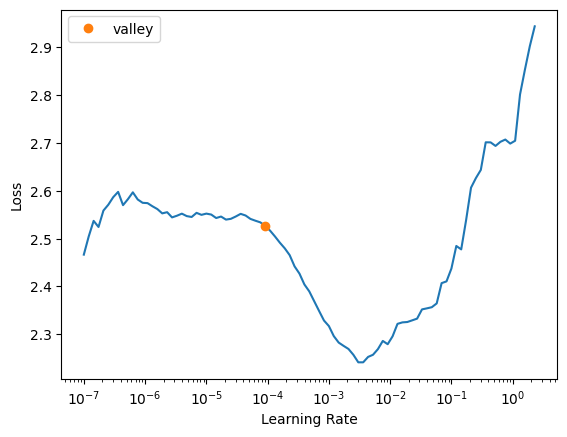

In [13]:
learn.lr_find()

In [14]:
lr = 1.3e-4
print("Learning rate:", lr)

Learning rate: 0.00013


In [15]:
learn.fine_tune(
    43,
    base_lr=lr
)

epoch,train_loss,valid_loss,accuracy,time
0,1.069037,0.798983,0.734870,01:25


epoch,train_loss,valid_loss,accuracy,time
0,0.663447,0.600015,0.803074,01:20
1,0.593080,0.532544,0.828050,01:19
2,0.498826,0.443091,0.860231,01:20
3,0.433909,0.395867,0.878963,01:22
4,0.381315,0.348903,0.896734,01:20
5,0.320204,0.299622,0.912584,01:19
6,0.277233,0.267379,0.924111,01:20
7,0.224183,0.233804,0.932757,01:20
8,0.216432,0.239369,0.938040,01:19
9,0.173911,0.203911,0.945245,01:20


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
from pathlib import Path

backup_path = Path('/content/drive/MyDrive/Paddy_Disease_Project')
backup_path.mkdir(parents=True, exist_ok=True)

print("Backup folder:", backup_path)

Backup folder: /content/drive/MyDrive/Paddy_Disease_Project


In [22]:
print(type(train_dataset))
print(type(val_dataset))

<class 'torch.utils.data.dataset.Subset'>
<class 'torch.utils.data.dataset.Subset'>


In [23]:
from torch.utils.data import Subset

def new_empty(self):
    return Subset(self.dataset, [])

Subset.new_empty = new_empty

In [24]:
from fastai.data.core import DataLoaders

dls = DataLoaders.from_dsets(
    train_dataset,
    val_dataset,
    bs=32,
    num_workers=2,
    device=device
)

print(dls)

In [25]:
learn.export(
    backup_path / 'resnet18_paddy_baseline.pkl'
)
print("Model exported successfully!")

Model exported successfully!
